## Test of Normality
Equity returns generally exhibit **excess kurtosis** (fat tails) and are not normally distributed.

In [1]:
library(nortest)   # ad.test (Anderson-Darling)
library(moments)   # normalTest (Jarque-Bera style)
library(ggplot2)
options(warn=-1)

In [15]:
stock <- read.csv("../../../data/TSLA.Daily.csv")
stock$returns <- c(NA, diff(stock$close) / stock$close[-nrow(stock)])
stock <- na.omit(stock)

## Frequency distribution vs. normal sample

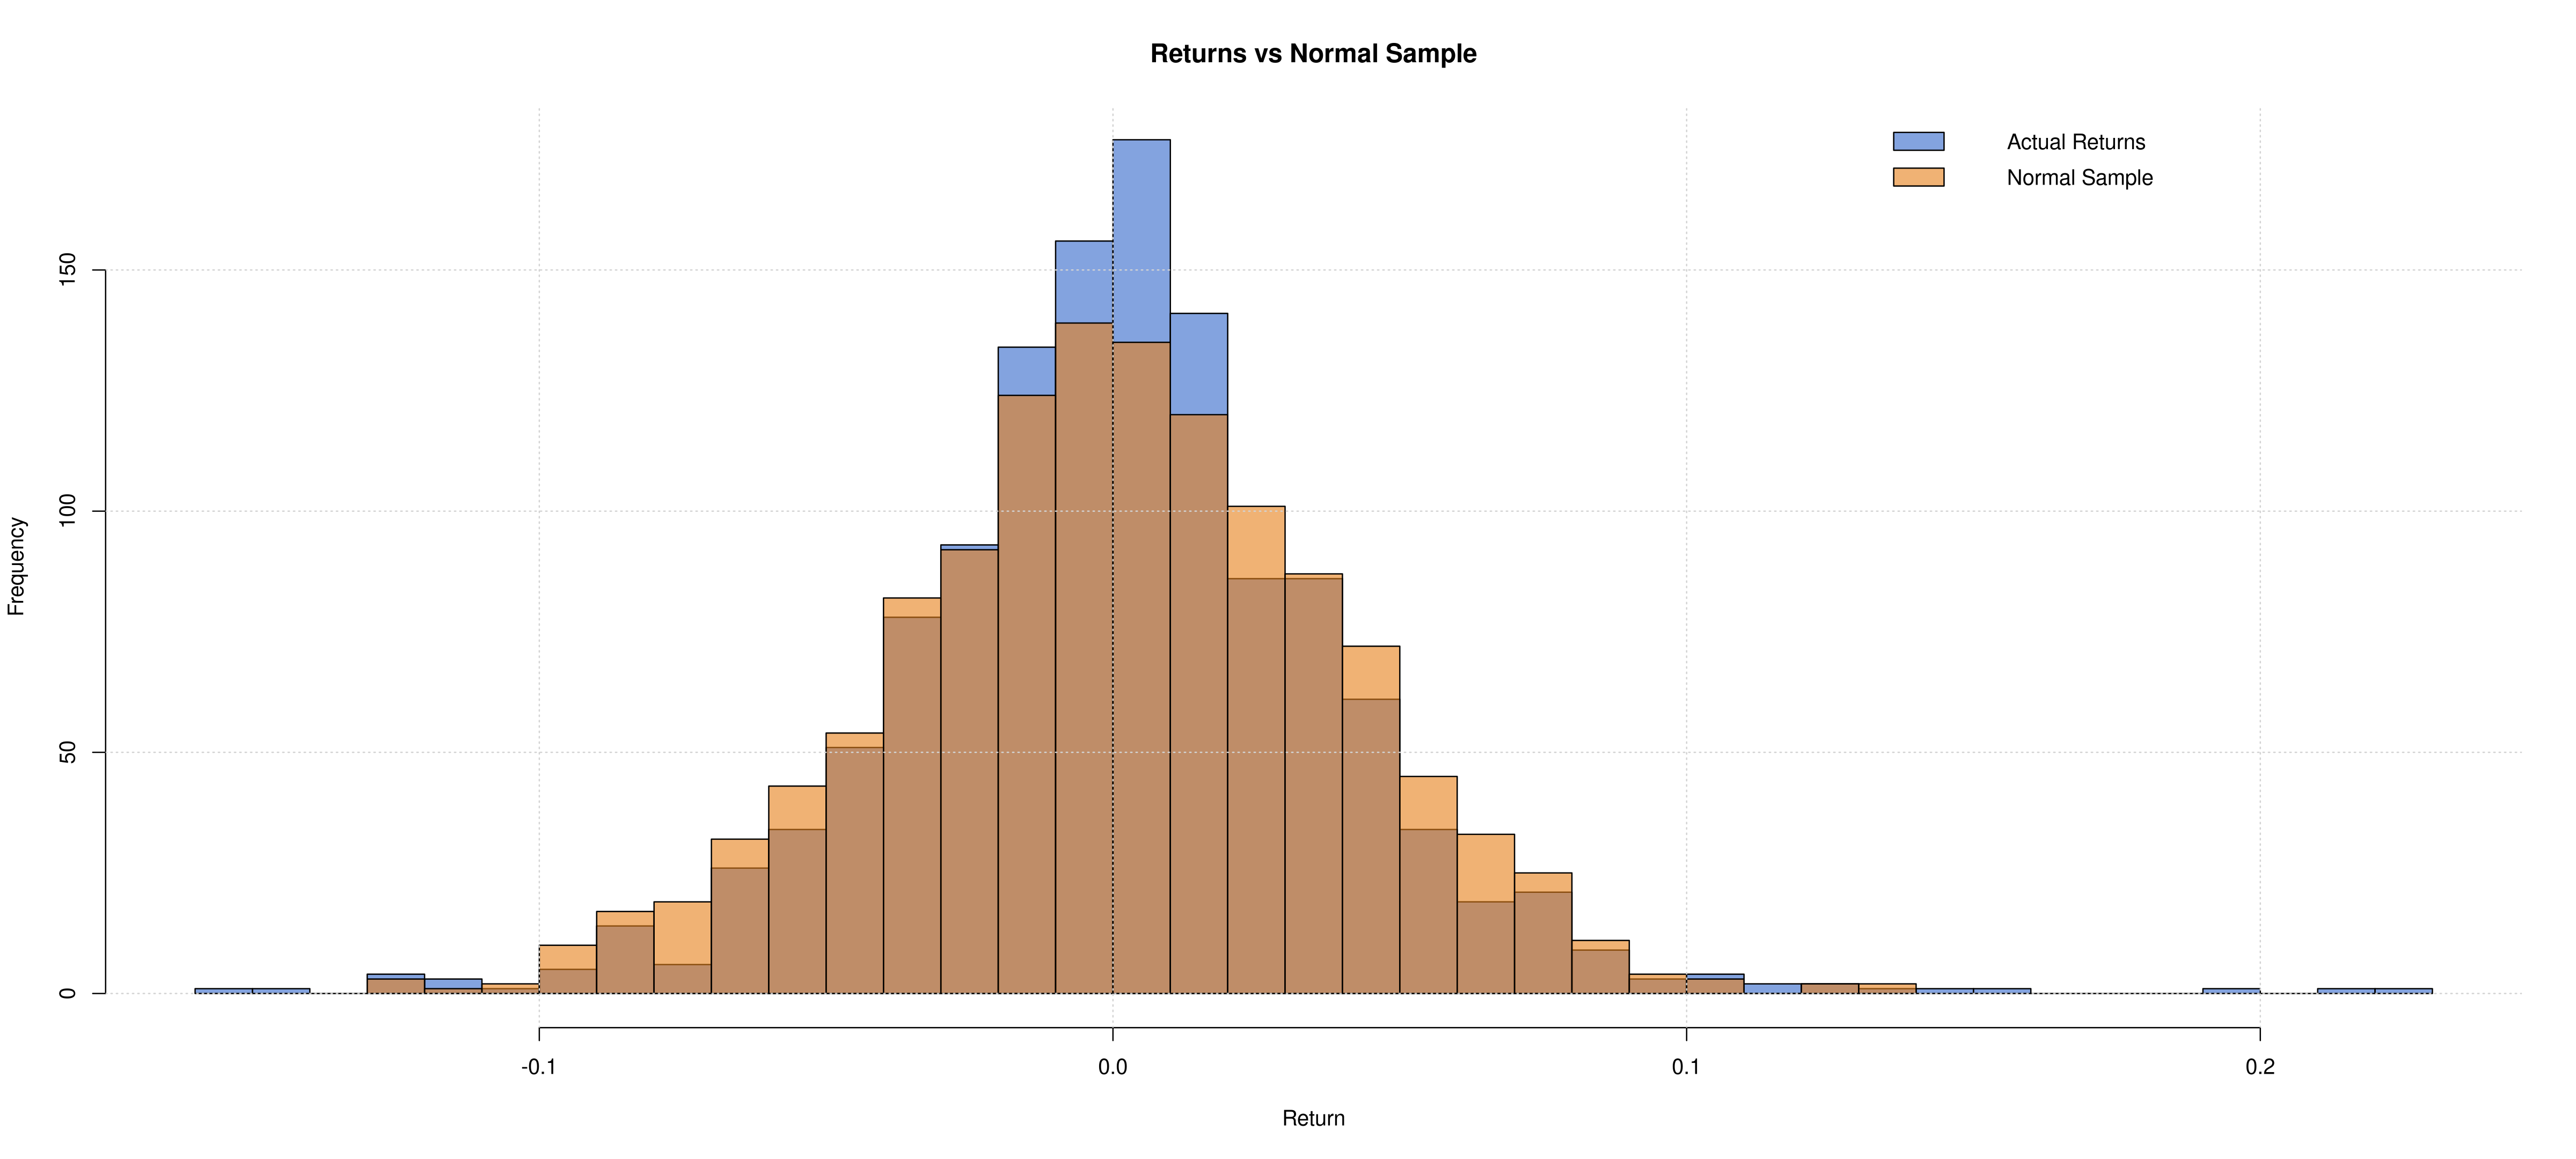

In [22]:
sample_data <- rnorm(nrow(stock), mean(stock$returns), sd(stock$returns))

par(mfrow=c(1,1))
hist(stock$returns, breaks=30, col=rgb(0.2,0.4,0.8,0.6),
     main="Returns vs Normal Sample", xlab="Return", freq=T)
hist(sample_data, breaks=30, col=rgb(0.9,0.5,0.1,0.6), add=TRUE, freq=T)
legend("topright", legend=c("Actual Returns","Normal Sample"),
       fill=c(rgb(0.2,0.4,0.8,0.6), rgb(0.9,0.5,0.1,0.6)), bty="n")
grid()

## Anderson-Darling Test
- **Null hypothesis:** Data is normally distributed
- Higher statistic → more likely to reject normality

In [23]:
return_ad <- ad.test(stock$returns)
sample_ad <- ad.test(sample_data)

cat(sprintf("Returns. A-D Statistic: %.4f  p-value: %.4f\n",
            return_ad$statistic, return_ad$p.value))
cat(sprintf("Sample.  A-D Statistic: %.4f  p-value: %.4f\n",
            sample_ad$statistic, sample_ad$p.value))

Returns. A-D Statistic: 5.9460  p-value: 0.0000
Sample.  A-D Statistic: 0.5870  p-value: 0.1260


## Shapiro-Wilk Test
- **Null hypothesis:** Data is normally distributed
- p < 0.05 → reject (not normally distributed)

In [24]:
# Shapiro-Wilk is limited to n <= 5000; sample if needed
max_n   <- min(nrow(stock), 5000)
ret_sw  <- shapiro.test(stock$returns[1:max_n])
samp_sw <- shapiro.test(sample_data[1:max_n])

sw_table <- data.frame(
    P.Val      = c(round(ret_sw$p.value,4),  round(samp_sw$p.value,4)),
    Statistics = c(round(ret_sw$statistic,4), round(samp_sw$statistic,4)),
    row.names  = c("Returns","Sample.Data")
)
print(sw_table)

             P.Val Statistics
Returns     0.0000     0.9698
Sample.Data 0.1418     0.9980


## Normality - Skewness & Kurtosis Test (Jarque-Bera)
- **Null hypothesis:** Data is normally distributed
- p < 0.05 → reject

In [25]:
library(moments)
ret_jb  <- jarque.test(stock$returns)
samp_jb <- jarque.test(sample_data)

jb_table <- data.frame(
    P.Val      = c(round(ret_jb$p.value,4),  round(samp_jb$p.value,4)),
    Statistics = c(round(ret_jb$statistic,4), round(samp_jb$statistic,4)),
    row.names  = c("Returns","Sample.Data")
)
print(jb_table)

             P.Val Statistics
Returns     0.0000   529.2178
Sample.Data 0.2266     2.9693


In [26]:
test_results <- data.frame(
    P.Val               = rep(NA_real_, 3),
    Statistics          = rep(NA_real_, 3),
    Normally.distributed = rep(NA_character_, 3),
    Reason              = rep(NA_character_, 3),
    row.names = c("Anderson-Darling","Shapiro-Wilk","Skewness-Kurtosis"),
    stringsAsFactors = FALSE
)

# Anderson-Darling
ad_res <- ad.test(stock$returns)
test_results["Anderson-Darling","Statistics"] <- round(ad_res$statistic,3)
if (ad_res$p.value <= 0.05) {
    test_results["Anderson-Darling","Normally.distributed"] <- "Likely Not"
    test_results["Anderson-Darling","Reason"] <- "p <= 0.05 rejects normality"
} else {
    test_results["Anderson-Darling","Normally.distributed"] <- "Likely"
    test_results["Anderson-Darling","Reason"] <- "p > 0.05 fails to reject normality"
}

# Shapiro-Wilk
sw_res <- shapiro.test(stock$returns[1:min(nrow(stock),5000)])
test_results["Shapiro-Wilk","P.Val"]      <- round(sw_res$p.value,4)
test_results["Shapiro-Wilk","Statistics"] <- round(sw_res$statistic,4)
if (sw_res$p.value <= 0.05) {
    test_results["Shapiro-Wilk","Normally.distributed"] <- "Likely Not"
    test_results["Shapiro-Wilk","Reason"] <- "p <= 0.05 rejects normality"
} else {
    test_results["Shapiro-Wilk","Normally.distributed"] <- "Likely"
    test_results["Shapiro-Wilk","Reason"] <- "p > 0.05 fails to reject normality"
}

# Jarque-Bera
jb_res <- jarque.test(stock$returns)
test_results["Skewness-Kurtosis","P.Val"]      <- round(jb_res$p.value,4)
test_results["Skewness-Kurtosis","Statistics"] <- round(jb_res$statistic,4)
if (jb_res$p.value <= 0.05) {
    test_results["Skewness-Kurtosis","Normally.distributed"] <- "Likely Not"
    test_results["Skewness-Kurtosis","Reason"] <- "p <= 0.05 rejects normality"
} else {
    test_results["Skewness-Kurtosis","Normally.distributed"] <- "Likely"
    test_results["Skewness-Kurtosis","Reason"] <- "p > 0.05 fails to reject normality"
}

print(test_results)

                  P.Val Statistics Normally.distributed
Anderson-Darling     NA     5.9460           Likely Not
Shapiro-Wilk          0     0.9698           Likely Not
Skewness-Kurtosis     0   529.2178           Likely Not
                                       Reason
Anderson-Darling  p <= 0.05 rejects normality
Shapiro-Wilk      p <= 0.05 rejects normality
Skewness-Kurtosis p <= 0.05 rejects normality
